In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from kan import *

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [6]:
iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [19]:
dtype = torch.get_default_dtype()
dataset = {}
dataset['train_input'] = torch.from_numpy(X_train).type(dtype).to(device)
dataset['test_input'] = torch.from_numpy(X_test).type(dtype).to(device)
dataset['train_label'] = torch.from_numpy(y_train).type(torch.long).to(device)
dataset['test_label'] = torch.from_numpy(y_test).type(torch.long).to(device)

In [20]:

# =====================================================
# 4. Crear modelo KAN
# =====================================================
import os
os.makedirs("./checkpoints_iris", exist_ok=True)

model = KAN(
    width=[4, 8, 3],
    grid=5,
    k=3,
    seed=1,
    device=device,
    ckpt_path="./checkpoints_iris"
    #auto_save=True
    #auto_save=False si no se quieren guardar los checkpoints durante el entrenamiento
)

checkpoint directory created: ./checkpoints_iris
saving model version 0.0


In [21]:
def train_acc():
    return torch.mean((torch.argmax(model(dataset['train_input']), dim=1) == dataset['train_label']).type(dtype))

def test_acc():
    return torch.mean((torch.argmax(model(dataset['test_input']), dim=1) == dataset['test_label']).type(dtype))

In [38]:
resultados = model.fit(dataset, 
            opt="LBFGS", 
            steps=30, 
            metrics=(train_acc, test_acc),
            loss_fn=torch.nn.CrossEntropyLoss(),
            lamb=0.01)

| train_loss: 1.04e-01 | test_loss: 3.76e-01 | reg: 1.29e+01 | : 100%|█| 30/30 [00:29<00:00,  1.02it

saving model version 0.2


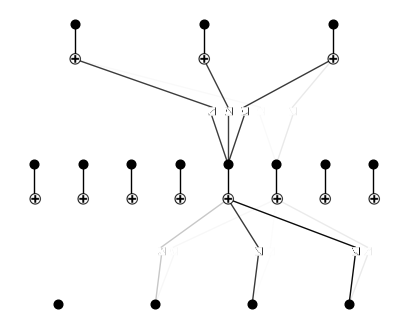

In [39]:
model.plot()

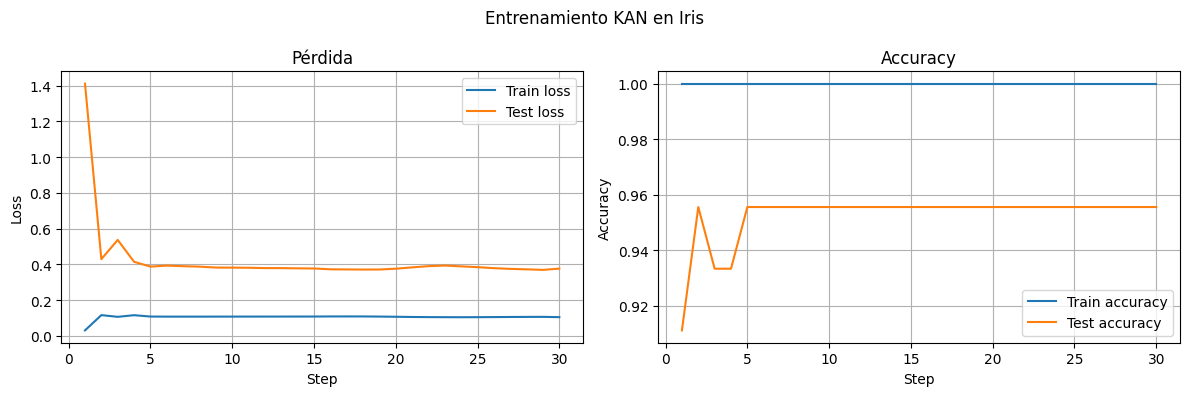

In [45]:
import matplotlib.pyplot as plt

train_loss = [float(v) for v in resultados["train_loss"]]
test_loss = [float(v) for v in resultados["test_loss"]]

train_acc_values = [float(v) for v in resultados["train_acc"]]
test_acc_values = [float(v) for v in resultados["test_acc"]]

steps = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# =====================================================
# Gráfica 1: Loss
# =====================================================
axes[0].plot(steps, train_loss, label="Train loss")
axes[0].plot(steps, test_loss, label="Test loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Pérdida")
axes[0].grid(True)
axes[0].legend()

# =====================================================
# Gráfica 2: Accuracy
# =====================================================
axes[1].plot(steps, train_acc_values, label="Train accuracy")
axes[1].plot(steps, test_acc_values, label="Test accuracy")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].grid(True)
axes[1].legend()

plt.suptitle("Entrenamiento KAN en Iris")
plt.tight_layout()
plt.show()

saving model version 0.3


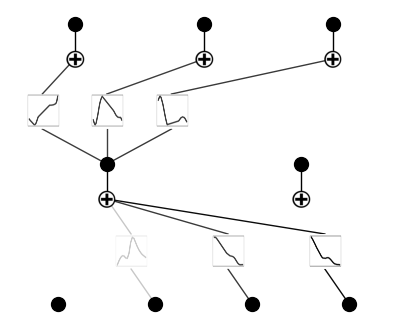

In [43]:
pruned_model = model.prune()
pruned_model.plot()

In [44]:
resultados_poda = pruned_model.fit(dataset, 
            opt="LBFGS", 
            steps=30, 
            metrics=(train_acc, test_acc),
            loss_fn=torch.nn.CrossEntropyLoss(),
            update_grid=False)

| train_loss: 4.77e-05 | test_loss: 1.25e+00 | reg: 2.64e+01 | : 100%|█| 30/30 [00:16<00:00,  1.82it

saving model version 0.4


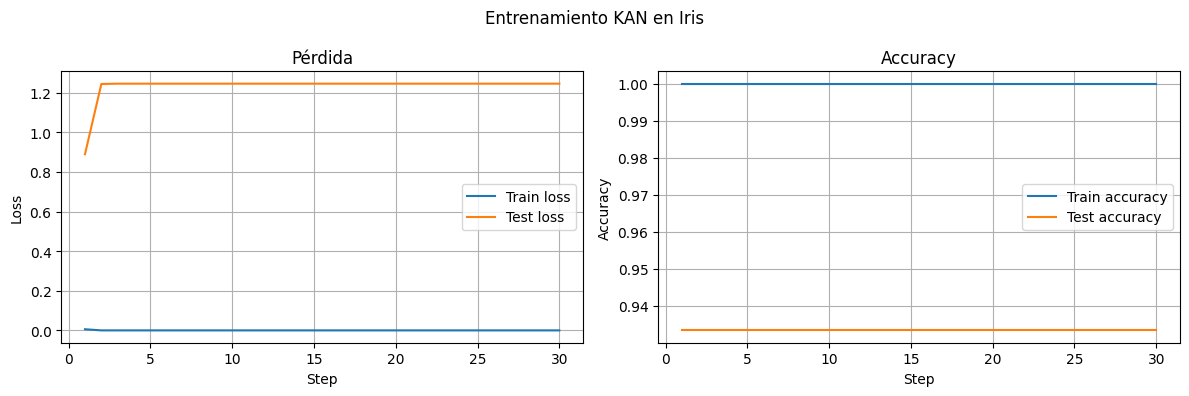

In [46]:
import matplotlib.pyplot as plt

train_loss = [float(v) for v in resultados_poda["train_loss"]]
test_loss = [float(v) for v in resultados_poda["test_loss"]]

train_acc_values = [float(v) for v in resultados_poda["train_acc"]]
test_acc_values = [float(v) for v in resultados_poda["test_acc"]]

steps = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# =====================================================
# Gráfica 1: Loss
# =====================================================
axes[0].plot(steps, train_loss, label="Train loss")
axes[0].plot(steps, test_loss, label="Test loss")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Pérdida")
axes[0].grid(True)
axes[0].legend()

# =====================================================
# Gráfica 2: Accuracy
# =====================================================
axes[1].plot(steps, train_acc_values, label="Train accuracy")
axes[1].plot(steps, test_acc_values, label="Test accuracy")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].grid(True)
axes[1].legend()

plt.suptitle("Entrenamiento KAN en Iris")
plt.tight_layout()
plt.show()

In [48]:
print("Width original:", model.width_out)
print("Máscaras antes de poda:")

for i, layer in enumerate(model.act_fun):
    print(f"\nLayer {i}")
    print(layer.mask)

print("\n============================\n")
print("Width podado:", pruned_model.width_out)
print("Máscaras después de poda:")

for i, layer in enumerate(pruned_model.act_fun):
    print(f"\nLayer {i}")
    print(layer.mask)

Width original: [4, 8, 3]
Máscaras antes de poda:

Layer 0
Parameter containing:
tensor([[0., 0., 0., 0., 1., 1., 0., 0.],
        [0., 0., 0., 0., 1., 1., 0., 0.],
        [0., 0., 0., 0., 1., 1., 0., 0.],
        [0., 0., 0., 0., 1., 1., 0., 0.]], device='cuda:0')

Layer 1
Parameter containing:
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [1., 1., 1.],
        [1., 1., 1.],
        [0., 0., 0.],
        [0., 0., 0.]], device='cuda:0')


Width podado: [4, 2, 3]
Máscaras después de poda:

Layer 0
Parameter containing:
tensor([[0., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.]], device='cuda:0')

Layer 1
Parameter containing:
tensor([[1., 1., 1.],
        [0., 0., 0.]], device='cuda:0')


In [49]:
# =====================================================
# 3. Predicciones
# =====================================================
model.eval()

with torch.no_grad():
    logits_train = model(dataset["train_input"])
    logits_test = model(dataset["test_input"])

    y_pred_train = torch.argmax(logits_train, dim=1)
    y_pred_test = torch.argmax(logits_test, dim=1)

y_train_true = dataset["train_label"].detach().cpu().numpy()
y_test_true = dataset["test_label"].detach().cpu().numpy()

y_train_pred = y_pred_train.detach().cpu().numpy()
y_test_pred = y_pred_test.detach().cpu().numpy()


pruned_model.eval()

with torch.no_grad():
    logits_train_p = pruned_model(dataset["train_input"])
    logits_test_p = pruned_model(dataset["test_input"])

    y_pred_train_p = torch.argmax(logits_train_p, dim=1)
    y_pred_test_p = torch.argmax(logits_test_p, dim=1)

y_train_pred_p = y_pred_train_p.detach().cpu().numpy()
y_test_pred_p = y_pred_test_p.detach().cpu().numpy()

In [50]:
# =====================================================
# 4. Métricas
# =====================================================
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("\nAccuracy train:", accuracy_score(y_train_true, y_train_pred))
print("Accuracy test :", accuracy_score(y_test_true, y_test_pred))

print("\nReporte de clasificación - TRAIN")
print(classification_report(
    y_train_true,
    y_train_pred,
    target_names=iris.target_names
))

print("\nReporte de clasificación - TEST")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=iris.target_names
))


print("\nAccuracy train:", accuracy_score(y_train_true, y_train_pred_p))
print("Accuracy test :", accuracy_score(y_test_true, y_test_pred_p))

print("\nReporte de clasificación - TRAIN")
print(classification_report(
    y_train_true,
    y_train_pred_p,
    target_names=iris.target_names
))

print("\nReporte de clasificación - TEST")
print(classification_report(
    y_test_true,
    y_test_pred_p,
    target_names=iris.target_names
))


Accuracy train: 1.0
Accuracy test : 0.9333333333333333

Reporte de clasificación - TRAIN
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        35
  versicolor       1.00      1.00      1.00        35
   virginica       1.00      1.00      1.00        35

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105


Reporte de clasificación - TEST
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


Accuracy train: 1.0
Accuracy test : 0.9111111111111111

Reporte de clasificación - TRAIN
              precision  

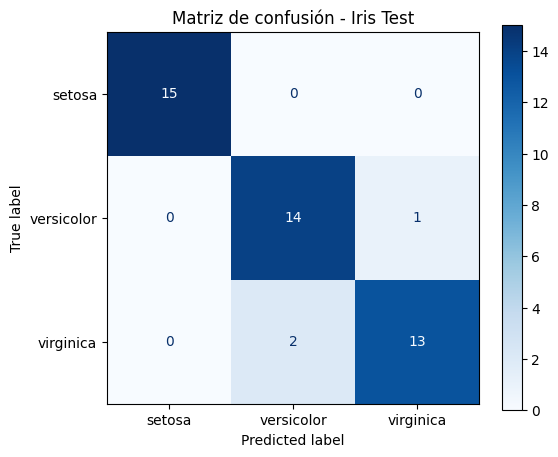

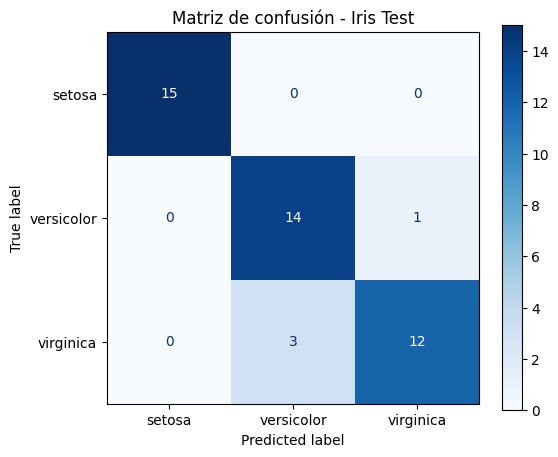

In [51]:
# =====================================================
# 5. Matriz de confusión
# =====================================================
cm = confusion_matrix(y_test_true, y_test_pred)
cm_p = confusion_matrix(y_test_true, y_test_pred_p)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp_p = ConfusionMatrixDisplay(
    confusion_matrix=cm_p,
    display_labels=iris.target_names
)


fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matriz de confusión - Iris Test")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
disp_p.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matriz de confusión - Iris Test")
plt.show()

In [32]:
# =====================================================
# 6. Tabla de predicciones
# =====================================================
df_pred = pd.DataFrame({
    "y_real": y_test_true,
    "y_pred": y_test_pred,
    "clase_real": [iris.target_names[i] for i in y_test_true],
    "clase_predicha": [iris.target_names[i] for i in y_test_pred],
    "correcto": y_test_true == y_test_pred
})

display(df_pred.head(10))

print("\nErrores:")
display(df_pred[df_pred["correcto"] == False])

,y_real,y_pred,clase_real,clase_predicha,correcto
0,2,2,virginica,virginica,True
1,1,1,versicolor,versicolor,True
2,2,1,virginica,versicolor,False
3,1,1,versicolor,versicolor,True
4,2,2,virginica,virginica,True
5,2,2,virginica,virginica,True
6,1,1,versicolor,versicolor,True
7,1,1,versicolor,versicolor,True
8,0,0,setosa,setosa,True
9,2,2,virginica,virginica,True



Errores:


,y_real,y_pred,clase_real,clase_predicha,correcto
2,2,1,virginica,versicolor,False
30,2,1,virginica,versicolor,False
32,1,0,versicolor,setosa,False
39,1,2,versicolor,virginica,False
42,2,1,virginica,versicolor,False


In [34]:
def predecir_iris(model, scaler, muestras, iris, device, dtype):
    """
    Predice la clase de nuevas flores Iris.

    Parámetros
    ----------
    model : KAN entrenada
    scaler : StandardScaler ajustado con X_train
    muestras : np.ndarray
        Matriz con forma [n_muestras, 4].
        Columnas:
        sepal length, sepal width, petal length, petal width.
    iris : objeto de load_iris()
    device : torch.device
    dtype : tipo de dato torch
    """

    # Escalar con el mismo scaler del entrenamiento
    muestras_scaled = scaler.transform(muestras)

    # Convertir a tensor
    muestras_t = torch.tensor(
        muestras_scaled,
        dtype=dtype
    ).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(muestras_t)
        probs = torch.softmax(logits, dim=1)
        pred_classes = torch.argmax(probs, dim=1)

    pred_classes_np = pred_classes.detach().cpu().numpy()
    probs_np = probs.detach().cpu().numpy()

    resultados_pred = []

    for i, clase in enumerate(pred_classes_np):
        resultados_pred.append({
            "muestra": i + 1,
            "clase_predicha": iris.target_names[clase],
            "prob_setosa": probs_np[i, 0],
            "prob_versicolor": probs_np[i, 1],
            "prob_virginica": probs_np[i, 2],
        })

    return pd.DataFrame(resultados_pred)

In [35]:
flores_nuevas = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.0, 2.9, 4.5, 1.5],
    [6.5, 3.0, 5.8, 2.2],
])

df_nuevas = predecir_iris(
    model=model,
    scaler=scaler,
    muestras=flores_nuevas,
    iris=iris,
    device=device,
    dtype=dtype
)

df_nuevas

,muestra,clase_predicha,prob_setosa,prob_versicolor,prob_virginica
0,1,setosa,1.000000e+00,0.0,0.000000e+00
1,2,versicolor,3.066073e-26,1.0,4.201804e-20
2,3,virginica,0.000000e+00,0.0,1.000000e+00
